In [1]:
set.seed(405)
options(stringsAsFactors = FALSE)

In [2]:
required_packages <- c("rstan", "dplyr", "readr", "tibble", "tidyr", "ggplot2")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”

Attaching package: ‘tidyr’


The following object is masked from ‘package:rstan’:

    extract


Warning message:
“package ‘ggplot

In [3]:
model_tbl <- readr::read_csv("../output/derived/gss_2024_model_table.csv", show_col_types = FALSE) %>%
  dplyr::mutate(
    degree = as.factor(degree),
    sex = as.factor(sex),
    region = as.factor(region),
    polviews_bin = factor(polviews_bin, levels = c("Liberal", "Moderate", "Conservative"))
  )

m1_tbl <- model_tbl %>%
  dplyr::filter(!is.na(confinan_ord), !is.na(polviews), !is.na(age_std), !is.na(income_std), !is.na(degree), !is.na(sex), !is.na(region))
m2_tbl <- model_tbl %>%
  dplyr::filter(!is.na(confinan_ord), !is.na(polviews_bin), !is.na(age_std), !is.na(income_std), !is.na(degree), !is.na(sex), !is.na(region))

X_m1 <- stats::model.matrix(~ polviews + age_std + income_std + degree + sex + region, data = m1_tbl)
X_m1 <- X_m1[, colnames(X_m1) != "(Intercept)", drop = FALSE]

X_m2 <- stats::model.matrix(~ age_std + income_std + degree + sex + region, data = m2_tbl)
X_m2 <- X_m2[, colnames(X_m2) != "(Intercept)", drop = FALSE]
ideology_id <- as.integer(m2_tbl$polviews_bin)

tibble::tibble(metric = c("m1_N", "m1_K", "m2_N", "m2_K", "m2_G"), value = c(nrow(X_m1), ncol(X_m1), nrow(X_m2), ncol(X_m2), length(levels(m2_tbl$polviews_bin))))

metric,value
<chr>,<int>
m1_N,2223
m1_K,11
m2_N,2223
m2_K,10
m2_G,3


In [4]:
inv_logit <- function(z) 1 / (1 + exp(-z))

draw_ordered <- function(eta, c1, c2) {
  p1 <- inv_logit(c1 - eta)
  p2 <- inv_logit(c2 - eta) - p1
  p3 <- 1 - p1 - p2
  probs <- cbind(p1, p2, p3)
  y <- apply(probs, 1, function(pr) sample.int(3, size = 1, prob = pmax(pr, 1e-8)))
  as.integer(y)
}

simulate_model1 <- function(X) {
  K <- ncol(X)
  beta_true <- seq(-0.25, 0.25, length.out = K)
  c_true <- c(-1.2, 1.0)
  eta <- as.numeric(X %*% beta_true)
  y <- draw_ordered(eta, c_true[1], c_true[2])
  list(y = y, beta_true = beta_true, c_true = c_true)
}

simulate_model2 <- function(X, ideology_id, G) {
  K <- ncol(X)
  beta_true <- seq(-0.2, 0.2, length.out = K)
  mu_alpha_true <- 0.1
  sigma_alpha_true <- 0.35
  alpha_true <- c(-0.25, 0.05, 0.25)
  c_true <- c(-1.1, 1.1)
  eta <- as.numeric(alpha_true[ideology_id] + X %*% beta_true)
  y <- draw_ordered(eta, c_true[1], c_true[2])
  list(y = y, beta_true = beta_true, c_true = c_true, mu_alpha_true = mu_alpha_true, sigma_alpha_true = sigma_alpha_true, alpha_true = alpha_true)
}

sim_m1 <- simulate_model1(X_m1)
sim_m2 <- simulate_model2(X_m2, ideology_id, G = length(levels(m2_tbl$polviews_bin)))

In [5]:
stan_data_m1_syn <- list(N = nrow(X_m1), K = ncol(X_m1), y = sim_m1$y, X = X_m1)
stan_data_m2_syn <- list(N = nrow(X_m2), K = ncol(X_m2), G = length(levels(m2_tbl$polviews_bin)), y = sim_m2$y, X = X_m2, ideology_id = ideology_id)

sm_m1 <- rstan::stan_model(file = "../stan/model1_pooled_ordinal.stan", model_name = "model1_pooled_ordinal")
sm_m2 <- rstan::stan_model(file = "../stan/model2_hierarchical_ordinal.stan", model_name = "model2_hierarchical_ordinal")

recompiling to avoid crashing R session

recompiling to avoid crashing R session



In [6]:
fit_m1_syn <- rstan::sampling(
  object = sm_m1,
  data = stan_data_m1_syn,
  chains = 2,
  iter = 1200,
  warmup = 600,
  seed = 405,
  refresh = 0,
  control = list(adapt_delta = 0.9)
)

fit_m2_syn <- rstan::sampling(
  object = sm_m2,
  data = stan_data_m2_syn,
  chains = 2,
  iter = 1200,
  warmup = 600,
  seed = 406,
  refresh = 0,
  control = list(adapt_delta = 0.9)
)

In [7]:
summarize_recovery <- function(fit_obj, truth_named, model_label) {
  s <- as.data.frame(rstan::summary(fit_obj)$summary, check.names = FALSE)
  s$parameter <- rownames(s)
  s <- s %>% dplyr::relocate(parameter)

  truth_tbl <- tibble::tibble(parameter = names(truth_named), true_value = as.numeric(truth_named))

  out <- s %>%
    dplyr::inner_join(truth_tbl, by = "parameter") %>%
    dplyr::transmute(
      model = model_label,
      parameter,
      true_value,
      post_mean = mean,
      q025 = `2.5%`,
      q975 = `97.5%`,
      covered = (q025 <= true_value) & (q975 >= true_value),
      abs_error = abs(post_mean - true_value),
      Rhat
    )
  out
}

truth_m1 <- c(setNames(sim_m1$beta_true, paste0("beta[", seq_along(sim_m1$beta_true), "]")), setNames(sim_m1$c_true, c("c[1]", "c[2]")))
truth_m2 <- c(
  setNames(sim_m2$beta_true, paste0("beta[", seq_along(sim_m2$beta_true), "]")),
  setNames(sim_m2$c_true, c("c[1]", "c[2]")),
  c(mu_alpha = sim_m2$mu_alpha_true, sigma_alpha = sim_m2$sigma_alpha_true),
  setNames(sim_m2$alpha_true, c("alpha[1]", "alpha[2]", "alpha[3]"))
)

rec_m1 <- summarize_recovery(fit_m1_syn, truth_m1, "Model1")
rec_m2 <- summarize_recovery(fit_m2_syn, truth_m2, "Model2")
recovery_tbl <- dplyr::bind_rows(rec_m1, rec_m2)

recovery_metrics <- recovery_tbl %>%
  dplyr::group_by(model) %>%
  dplyr::summarise(
    n_params = dplyr::n(),
    coverage_rate = mean(covered),
    median_abs_error = stats::median(abs_error),
    max_rhat = max(Rhat, na.rm = TRUE),
    .groups = "drop"
  )

recovery_metrics

model,n_params,coverage_rate,median_abs_error,max_rhat
<chr>,<int>,<dbl>,<dbl>,<dbl>
Model1,13,1.0000000,0.06459075,1.008143
Model2,17,0.9411765,0.08735464,1.004732


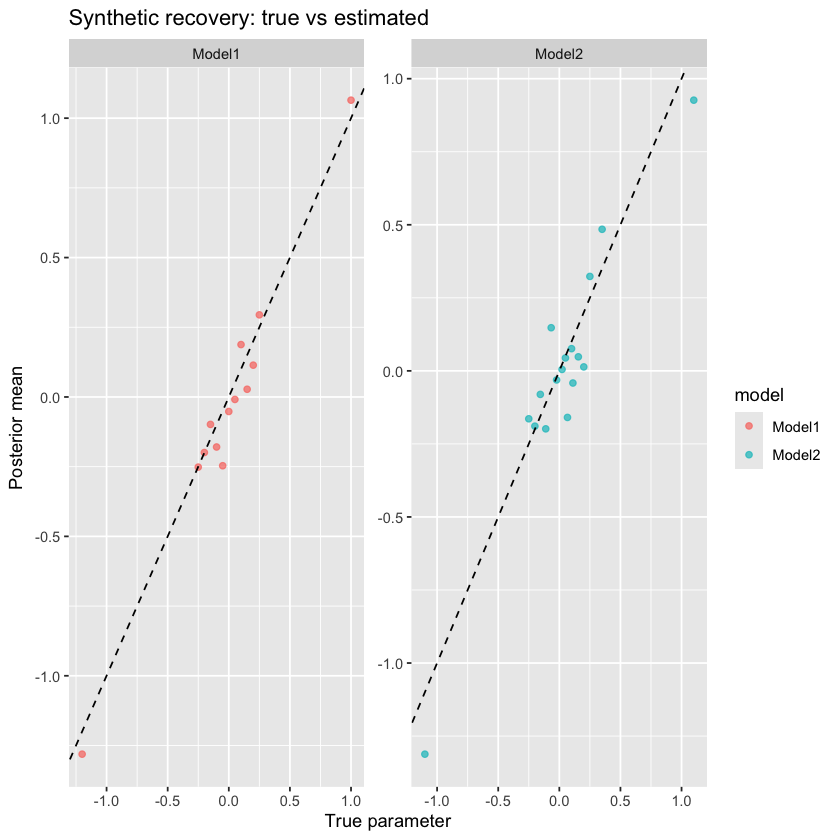

In [8]:
p_recovery <- ggplot2::ggplot(recovery_tbl, ggplot2::aes(x = true_value, y = post_mean, color = model)) +
  ggplot2::geom_point(alpha = 0.7) +
  ggplot2::geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  ggplot2::facet_wrap(~ model, scales = "free") +
  ggplot2::labs(x = "True parameter", y = "Posterior mean", title = "Synthetic recovery: true vs estimated")

p_abs_error <- ggplot2::ggplot(recovery_tbl, ggplot2::aes(x = parameter, y = abs_error, fill = model)) +
  ggplot2::geom_col() +
  ggplot2::facet_wrap(~ model, scales = "free_x") +
  ggplot2::labs(x = "parameter", y = "|posterior mean - true|", title = "Synthetic recovery absolute error")

p_recovery

In [9]:
dir.create("../output/validation", recursive = TRUE, showWarnings = FALSE)
saveRDS(fit_m1_syn, file = "../output/validation/fit_m1_synthetic.rds")
saveRDS(fit_m2_syn, file = "../output/validation/fit_m2_synthetic.rds")
readr::write_csv(recovery_tbl, "../output/validation/recovery_table.csv")
readr::write_csv(recovery_metrics, "../output/validation/recovery_metrics.csv")
ggplot2::ggsave(filename = "../output/validation/recovery_scatter.png", plot = p_recovery, width = 7, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/validation/recovery_abs_error.png", plot = p_abs_error, width = 8, height = 4.5, dpi = 150)